In [1]:
import pandas as pd

df = pd.read_csv('../data/preprocessed/cpdb_objectives_master.csv')

In [2]:


# So we only have the text features and the classification

# Need to create the text features column first

df['text_features'] = (
    df['policy_name'].fillna('') + " " + 
    df['policy_instrument'].fillna('') + " " + 
    df['sector'].fillna('') + " " +
    df['policy_type'].fillna('') + " " +
    df['policy_description'].fillna('')
)

df = df[['text_features', 'classification']]
print(df.head())

                                       text_features   classification
0  Adaptation Platform Canada (2012) Strategic pl...  adaptation only
1  Canadian Agricultural Adaptation Program Canad...  adaptation only
2  Climate Change Adaptation Act Japan (2015) Pol...  adaptation only
3  Climate Ready States and Cities Initiative Uni...  adaptation only
4  Climate Ready Water Utilities (CRWU) United St...  adaptation only


In [3]:
#When creating a classifier we need to split our data into 
#training and test sets
#we train on a portion of the data and test on another portion of the data
#important that these samples are performed randomly 
train = df.sample(frac = 0.8)
test = df.drop(train.index)
print(train.shape)
print(test.shape)

(5074, 2)
(1269, 2)


In [4]:
#sklearn is a very large library
#therefore we typically import only the functions we are actually going to use
from sklearn.feature_extraction.text import CountVectorizer

#A 'vectorizer' turns text data into a numeric matrix
#which can then be used by the model
vectorizer = CountVectorizer()
train_vectors = vectorizer.fit_transform(train['text_features'])
test_vectors = vectorizer.transform(test['text_features'])
#nb diff between transform and fit transform

In [5]:
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier()
clf.fit(train_vectors, train['classification'])
test['pred'] = clf.predict(test_vectors)

In [6]:
test.head()

,text_features,classification,pred
7,FEMA Federal Flood Risk Management Standard Un...,adaptation only,mitigation only
8,National Adaptation Strategy Turkey (2013) Str...,adaptation only,mitigation only
11,National Climate Resilience and Adaptation Str...,adaptation only,adaptation only
15,National Policy of Disaster Management India (...,adaptation only,adaptation only
28,"Decree No. 0672 on the creation, power, and op...",adaptation only,mitigation only


In [7]:
#definitions can be found here: 
#https://medium.com/@shrutisaxena0617/precision-vs-recall-386cf9f89488
from sklearn import metrics
print(metrics.accuracy_score(test['classification'], test['pred']))
print(metrics.precision_score(test['classification'], test['pred'], average='macro'))
print(metrics.recall_score(test['classification'], test['pred'], average='macro'))

0.9243498817966903
0.7237470039980104
0.6938339438339439


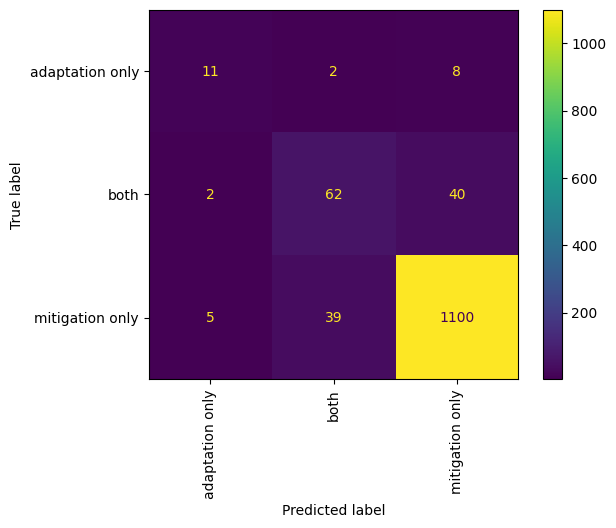

In [8]:
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(test['classification'], test['pred'], labels=clf.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=clf.classes_)
disp.plot(xticks_rotation = 'vertical')
plt.show()